# Workforce Intelligence & Employee Attrition Analytics

## Project Overview

This project analyzes employee demographics, compensation, job satisfaction, work experience, and attrition patterns using HR workforce data.

## Business Objectives

- Understand workforce composition and employee retention patterns.
- Identify employee groups with higher attrition rates.
- Explore relationships between overtime, salary, satisfaction, and attrition.
- Translate analytical findings into actionable HR recommendations.

## Tools & Technologies

- **Python:** Pandas, NumPy, Matplotlib, Seaborn
- **SQL:** Business-focused workforce analysis
- **Power BI:** Interactive HR dashboards

## Analytical Approach

1. Data loading and quality assessment
2. Data cleaning and validation
3. Exploratory data analysis (EDA)
4. Statistical analysis and business interpretation
5. Dashboard development and recommendations

## 1. Data Loading & Initial Data Quality Assessment

This section loads the HR employee dataset and performs an initial inspection of its structure, completeness, uniqueness, and column characteristics.

In [1]:



  

# ============================================================
# WORKFORCE INTELLIGENCE & EMPLOYEE ATTRITION ANALYTICS
# Exploratory Data Analysis (EDA)
# ============================================================
# Purpose:
# 1. Load and inspect the IBM HR Employee Attrition dataset.
# 2. Check data quality and validate business rules.
# 3. Clean the dataset and save the cleaned version.
# 4. Explore attrition patterns across important HR factors.
# 5. Test the association between overtime and attrition
#    among Sales Representatives.
#
# Tools: Python, Pandas, NumPy, SciPy
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# SciPy is used for the chi-square statistical test.
# If SciPy is unavailable, the remaining EDA can still run.
try:
    from scipy.stats import chi2_contingency
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("SciPy is unavailable. Statistical testing will be skipped.")


# ------------------------------------------------------------
# 2. DEFINE FILE PATHS AND LOAD THE DATASET
# ------------------------------------------------------------

# Update these paths if your files are stored elsewhere.
RAW_FILE = (
    r"C:\Users\HP\Desktop\Workforce_Intelligence_Analytics"
    r"\data\dataset.csv"
)

CLEAN_FILE = (
    r"C:\Users\HP\Desktop\Workforce_Intelligence_Analytics"
    r"\data\HR_Employee_Attrition_Clean.csv"
)

# Load the original HR dataset into a DataFrame.
df = pd.read_csv(RAW_FILE)

print("=" * 65)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 65)

# Display the dataset dimensions without printing all 1,470 rows.
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Preview the first five records.
display(df.head())


# ------------------------------------------------------------
# 3. INITIAL DATA QUALITY ASSESSMENT
# ------------------------------------------------------------

# Inspect column names, data types and non-null counts.
print("\n--- DATASET STRUCTURE ---")
df.info()

# Count missing values in each column.
print("\n--- MISSING VALUES BY COLUMN ---")
print(df.isnull().sum())

print("\nTotal missing values:", int(df.isnull().sum().sum()))

# Identify completely duplicated rows.
print("\n--- DUPLICATE ROWS ---")
print("Duplicate rows:", int(df.duplicated().sum()))

# Check whether EmployeeNumber uniquely identifies employees.
print("\n--- EMPLOYEE IDENTIFIER CHECK ---")
print("Unique employee numbers:", df["EmployeeNumber"].nunique())
print("Duplicate employee numbers:",
      int(df["EmployeeNumber"].duplicated().sum()))

# Identify columns containing only one unique value.
# Constant columns generally provide no analytical value.
constant_columns = df.columns[df.nunique(dropna=False) <= 1].tolist()

print("\n--- CONSTANT COLUMNS ---")
print(constant_columns)

# Examine the number of distinct values in each column.
print("\n--- UNIQUE VALUES PER COLUMN ---")
print(df.nunique(dropna=False).sort_values())

# Review the overall distribution of the target variable.
print("\n--- OVERALL ATTRITION DISTRIBUTION ---")
print(df["Attrition"].value_counts(dropna=False))

print("\n--- ATTRITION DISTRIBUTION (%) ---")
print(
    (df["Attrition"].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
)

# Generate descriptive statistics for numerical columns.
print("\n--- NUMERICAL DESCRIPTIVE STATISTICS ---")
display(df.describe().T)

# Check the number of unique values in categorical columns.
print("\n--- CATEGORICAL COLUMN CARDINALITY ---")
display(df.select_dtypes(include=["object"]).nunique())


# ------------------------------------------------------------
# 4. INSPECT CATEGORICAL VALUES
# ------------------------------------------------------------

# Print distinct values to identify inconsistent labels,
# unexpected categories or spelling differences.
print("\n--- DISTINCT CATEGORICAL VALUES ---")

for col in df.select_dtypes(include=["object"]).columns:
    print(f"\n{col}:")
    print(df[col].dropna().unique())


# ------------------------------------------------------------
# 5. VALIDATE BASIC BUSINESS RULES
# ------------------------------------------------------------

# Check for values that would be suspicious under the
# basic validation rules used in this project.
# These are validation checks, not automatic deletion rules.

checks = {
    "Age below 18": int((df["Age"] < 18).sum()),
    "Age above 70": int((df["Age"] > 70).sum()),
    "Monthly income <= 0": int((df["MonthlyIncome"] <= 0).sum()),
    "Years at company < 0": int((df["YearsAtCompany"] < 0).sum()),
    "Total working years < 0": int((df["TotalWorkingYears"] < 0).sum()),
    "Distance from home <= 0": int((df["DistanceFromHome"] <= 0).sum())
}

print("\n--- BUSINESS RULE VALIDATION ---")
for rule, count in checks.items():
    print(f"{rule}: {count}")


# ------------------------------------------------------------
# 6. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ------------------------------------------------------------

# Separate columns by their stored data types.
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("\n--- COLUMN TYPE SUMMARY ---")
print(f"Numerical columns: {len(numeric_cols)}")
print(numeric_cols)

print(f"\nCategorical columns: {len(categorical_cols)}")
print(categorical_cols)


# ------------------------------------------------------------
# 7. CLEAN THE DATASET
# ------------------------------------------------------------

# These columns are constant in the standard IBM HR dataset
# and do not contribute useful variation to the analysis.
# errors="ignore" prevents a failure if a column is absent.
df_clean = df.drop(
    columns=["EmployeeCount", "Over18", "StandardHours"],
    errors="ignore"
).copy()

# Check for leading or trailing whitespace in text columns.
print("\n--- WHITESPACE CHECK ---")

for col in df_clean.select_dtypes(include=["object"]).columns:
    spaces = (
        df_clean[col].notna()
        & df_clean[col].ne(df_clean[col].str.strip())
    ).sum()

    print(f"{col}: {int(spaces)} values with surrounding whitespace")

# No automatic whitespace correction or outlier deletion is
# applied here because the original data was already checked.

print("\n--- CLEANED DATASET DIMENSIONS ---")
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

# Save the cleaned dataset for use in SQL and Power BI.
df_clean.to_csv(CLEAN_FILE, index=False)

print(f"\nCleaned dataset saved to:\n{CLEAN_FILE}")


# ------------------------------------------------------------
# 8. VERIFY THE CLEANED DATASET
# ------------------------------------------------------------

# Confirm the cleaned file can be read back successfully.
df_check = pd.read_csv(CLEAN_FILE)

print("\n--- FINAL DATA QUALITY SUMMARY ---")
print(f"Rows: {df_check.shape[0]}")
print(f"Columns: {df_check.shape[1]}")
print(f"Missing values: {int(df_check.isnull().sum().sum())}")
print(f"Duplicate rows: {int(df_check.duplicated().sum())}")
print(
    "Duplicate employee numbers:",
    int(df_check["EmployeeNumber"].duplicated().sum())
)

print("\nRemaining constant columns:")
print(df_check.columns[df_check.nunique(dropna=False) <= 1].tolist())


# ------------------------------------------------------------
# 9. CLASSIFY NUMERICAL VARIABLES
# ------------------------------------------------------------

# Ordinal variables have meaningful ordered categories.
# EmployeeNumber is an identifier, not a continuous measure.
ordinal_cols = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

identifier_cols = ["EmployeeNumber"]

# Continuous/count variables are numerical variables that
# are not in the ordinal or identifier lists.
continuous_cols = [
    col for col in df_clean.select_dtypes(include=["number"]).columns
    if col not in ordinal_cols + identifier_cols
]

print("\n--- NUMERICAL VARIABLE CLASSIFICATION ---")
print("\nOrdinal variables:")
print([col for col in ordinal_cols if col in df_clean.columns])

print("\nIdentifier variables:")
print([col for col in identifier_cols if col in df_clean.columns])

print("\nContinuous/count variables:")
print(continuous_cols)


# ------------------------------------------------------------
# 10. DETECT POTENTIAL OUTLIERS USING THE IQR METHOD
# ------------------------------------------------------------

# IQR = Q3 - Q1
# Lower boundary = Q1 - 1.5 * IQR
# Upper boundary = Q3 + 1.5 * IQR
#
# Outliers are flagged for investigation, not automatically
# removed. Some extreme values may be valid employee records.

if continuous_cols:
    Q1 = df_clean[continuous_cols].quantile(0.25)
    Q3 = df_clean[continuous_cols].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df_clean[continuous_cols] < lower_bound)
        | (df_clean[continuous_cols] > upper_bound)
    ).sum()

    print("\n--- POTENTIAL OUTLIERS BY VARIABLE ---")
    display(outlier_count.sort_values(ascending=False).to_frame(
        name="Potential_Outlier_Count"
    ))



DATASET LOADED SUCCESSFULLY
Number of rows: 1470
Number of columns: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



--- DATASET STRUCTURE ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0



--- CATEGORICAL COLUMN CARDINALITY ---


C:\Users\HP\AppData\Local\Temp\ipykernel_11908\1601284741.py:115: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.select_dtypes(include=["object"]).nunique())


Attrition         2
BusinessTravel    3
Department        3
EducationField    6
Gender            2
JobRole           9
MaritalStatus     3
Over18            1
OverTime          2
dtype: int64


--- DISTINCT CATEGORICAL VALUES ---

Attrition:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

BusinessTravel:
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

Department:
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

EducationField:
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

Gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

JobRole:
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

MaritalStatus:
<StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

Over18:
<StringArray>
['Y']
Length: 1, dtype: str

Ov

C:\Users\HP\AppData\Local\Temp\ipykernel_11908\1601284741.py:126: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:
C:\Users\HP\AppData\Local\Temp\ipykernel_11908\1601284741.py:159: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/

,Potential_Outlier_Count
TrainingTimesLastYear,238
MonthlyIncome,114
YearsSinceLastPromotion,107
YearsAtCompany,104
TotalWorkingYears,63
NumCompaniesWorked,52
YearsInCurrentRole,21
YearsWithCurrManager,14
MonthlyRate,0
DailyRate,0


## 2. Exploratory Data Analysis

This section examines employee attrition patterns across overtime, department, job role, job satisfaction, tenure, income, business travel, and workplace environment satisfaction.

The analysis focuses on employee counts, attrition rates, subgroup comparisons, and statistical evidence to identify workforce retention patterns.

### 2.1 Overall Workforce & Attrition Summary

This section establishes the overall workforce profile and measures employee attrition using employee counts, active employees, employees who left, and the overall attrition rate.

In [2]:
# ============================================================
# OVERALL WORKFORCE & ATTRITION SUMMARY
# ============================================================

# Total number of employees
total_employees = len(df_clean)

# Number of employees who left the organization
employees_left = (
    df_clean["Attrition"].eq("Yes").sum()
)

# Number of employees who are still working
active_employees = (
    df_clean["Attrition"].eq("No").sum()
)

# Overall attrition rate
attrition_rate = (
    employees_left / total_employees * 100
    if total_employees > 0 else 0
)

# Display key workforce KPIs
workforce_summary = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Active Employees",
        "Employees Who Left",
        "Overall Attrition Rate (%)"
    ],
    "Value": [
        total_employees,
        active_employees,
        employees_left,
        round(attrition_rate, 2)
    ]
})

display(workforce_summary)

,Metric,Value
0,Total Employees,1470.00
1,Active Employees,1233.00
2,Employees Who Left,237.00
3,Overall Attrition Rate (%),16.12


### 2.2 Attrition Analysis by Overtime

This analysis compares employee attrition rates between employees who work overtime and those who do not, helping identify whether overtime is associated with higher employee turnover.

In [3]:
# ============================================================
# ATTRITION ANALYSIS BY OVERTIME
# ============================================================

overtime_analysis = (
    df_clean.groupby("OverTime")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

# Calculate attrition rate as a percentage
overtime_analysis["Attrition_Rate_%"] = (
    overtime_analysis["Employees_Left"]
    / overtime_analysis["Total_Employees"]
    * 100
).round(2)

display(overtime_analysis)

,OverTime,Total_Employees,Employees_Left,Attrition_Rate_%
0,No,1054,110,10.44
1,Yes,416,127,30.53


### 2.3 Attrition Analysis by Department

This analysis compares employee attrition across departments to identify where workforce retention challenges are most pronounced.

In [4]:
# ============================================================
# ATTRITION ANALYSIS BY DEPARTMENT
# ============================================================

department_analysis = (
    df_clean.groupby("Department")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=(
            "Attrition",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

# Calculate department-wise attrition rate
department_analysis["Attrition_Rate_%"] = (
    department_analysis["Employees_Left"]
    / department_analysis["Total_Employees"]
    * 100
).round(2)

# Sort departments by attrition rate, highest first
department_analysis = department_analysis.sort_values(
    "Attrition_Rate_%",
    ascending=False
)

display(department_analysis)

,Department,Total_Employees,Employees_Left,Attrition_Rate_%
2,Sales,446,92,20.63
0,Human Resources,63,12,19.05
1,Research & Development,961,133,13.84


### 2.4 Attrition Analysis by Job Role

This analysis compares employee attrition across job roles to identify roles with the highest turnover rates and the largest contributions to total employee exits.

In [5]:
# ============================================================
# ATTRITION ANALYSIS BY JOB ROLE
# ============================================================

job_role_analysis = (
    df_clean.groupby("JobRole")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=(
            "Attrition",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

# Calculate attrition rate within each job role
job_role_analysis["Attrition_Rate_%"] = (
    job_role_analysis["Employees_Left"]
    / job_role_analysis["Total_Employees"]
    * 100
).round(2)

# Calculate each role's share of all employee exits
job_role_analysis["Share_of_Total_Exits_%"] = (
    job_role_analysis["Employees_Left"]
    / job_role_analysis["Employees_Left"].sum()
    * 100
).round(2)

# Rank roles by attrition rate, highest first
job_role_analysis = job_role_analysis.sort_values(
    "Attrition_Rate_%",
    ascending=False
)

display(job_role_analysis)

,JobRole,Total_Employees,Employees_Left,Attrition_Rate_%,Share_of_Total_Exits_%
8,Sales Representative,83,33,39.76,13.92
2,Laboratory Technician,259,62,23.94,26.16
1,Human Resources,52,12,23.08,5.06
7,Sales Executive,326,57,17.48,24.05
6,Research Scientist,292,47,16.10,19.83
4,Manufacturing Director,145,10,6.90,4.22
0,Healthcare Representative,131,9,6.87,3.80
3,Manager,102,5,4.90,2.11
5,Research Director,80,2,2.50,0.84


### 2.5 Attrition Analysis by Job Satisfaction

This analysis examines employee attrition across job satisfaction levels to understand whether reported job satisfaction is associated with employee turnover.

In [6]:
# ============================================================
# ATTRITION ANALYSIS BY JOB SATISFACTION
# ============================================================

satisfaction_analysis = (
    df_clean.groupby("JobSatisfaction")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=(
            "Attrition",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

# Calculate attrition rate for each satisfaction level
satisfaction_analysis["Attrition_Rate_%"] = (
    satisfaction_analysis["Employees_Left"]
    / satisfaction_analysis["Total_Employees"]
    * 100
).round(2)

# Display satisfaction levels in ascending order
satisfaction_analysis = satisfaction_analysis.sort_values(
    "JobSatisfaction"
)

display(satisfaction_analysis)

,JobSatisfaction,Total_Employees,Employees_Left,Attrition_Rate_%
0,1,289,66,22.84
1,2,280,46,16.43
2,3,442,73,16.52
3,4,459,52,11.33


### 2.6 Attrition Analysis by Monthly Income Band

This analysis compares attrition rates across monthly income bands to examine how employee compensation relates to workforce retention.

In [7]:
# ============================================================
# ATTRITION ANALYSIS BY MONTHLY INCOME BAND
# ============================================================

# Create income bands for comparison
income_band_analysis = df_clean.copy()

income_band_analysis["IncomeBand"] = pd.cut(
    income_band_analysis["MonthlyIncome"],
    bins=[0, 3000, 5000, 8000, 12000, float("inf")],
    labels=["<3K", "3K–5K", "5K–8K", "8K–12K", "12K+"],
    right=False
)

# Summarize employees and attrition within each band
income_analysis = (
    income_band_analysis.groupby("IncomeBand", observed=False)
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=(
            "Attrition",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

# Calculate attrition rate
income_analysis["Attrition_Rate_%"] = (
    income_analysis["Employees_Left"]
    / income_analysis["Total_Employees"]
    * 100
).round(2)

display(income_analysis)

,IncomeBand,Total_Employees,Employees_Left,Attrition_Rate_%
0,<3K,395,113,28.61
1,3K–5K,354,50,14.12
2,5K–8K,340,34,10.00
3,8K–12K,186,29,15.59
4,12K+,195,11,5.64


### 2.7 Attrition Analysis by Business Travel

This analysis compares attrition rates across business travel categories to examine whether frequent work-related travel is associated with employee turnover.

In [8]:
# ============================================================
# ATTRITION ANALYSIS BY BUSINESS TRAVEL
# ============================================================

travel_analysis = (
    df_clean.groupby("BusinessTravel")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=(
            "Attrition",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

# Calculate attrition rate for each travel category
travel_analysis["Attrition_Rate_%"] = (
    travel_analysis["Employees_Left"]
    / travel_analysis["Total_Employees"]
    * 100
).round(2)

# Sort categories by attrition rate, highest first
travel_analysis = travel_analysis.sort_values(
    "Attrition_Rate_%",
    ascending=False
)

display(travel_analysis)

,BusinessTravel,Total_Employees,Employees_Left,Attrition_Rate_%
1,Travel_Frequently,277,69,24.91
2,Travel_Rarely,1043,156,14.96
0,Non-Travel,150,12,8.00


### 2.8 Attrition Analysis by Environment Satisfaction

This analysis compares employee attrition across workplace environment satisfaction levels to identify patterns that may help HR understand employee retention challenges.

In [9]:
# ============================================================
# ATTRITION ANALYSIS BY ENVIRONMENT SATISFACTION
# ============================================================

environment_analysis = (
    df_clean.groupby("EnvironmentSatisfaction")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=(
            "Attrition",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

# Calculate attrition rate for each satisfaction level
environment_analysis["Attrition_Rate_%"] = (
    environment_analysis["Employees_Left"]
    / environment_analysis["Total_Employees"]
    * 100
).round(2)

# Display satisfaction levels from lowest to highest
environment_analysis = environment_analysis.sort_values(
    "EnvironmentSatisfaction"
)

display(environment_analysis)

,EnvironmentSatisfaction,Total_Employees,Employees_Left,Attrition_Rate_%
0,1,284,72,25.35
1,2,287,43,14.98
2,3,453,62,13.69
3,4,446,60,13.45


### 2.9 Attrition Analysis by Employee Tenure

This analysis examines employee attrition across years of service to identify tenure stages associated with higher turnover and potential retention opportunities.

In [ ]:
# ============================================================
# ATTRITION ANALYSIS BY YEARS AT COMPANY
# ============================================================

tenure_analysis = (
    df_clean.groupby("YearsAtCompany")
    .agg(
        Total_Employees=("Attrition", "size"),
        Employees_Left=(
            "Attrition",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

# Calculate attrition rate for each tenure value
tenure_analysis["Attrition_Rate_%"] = (
    tenure_analysis["Employees_Left"]
    / tenure_analysis["Total_Employees"]
    * 100
).round(2)

# Sort tenure values from lowest to highest
tenure_analysis = tenure_analysis.sort_values(
    "YearsAtCompany"
)

display(tenure_analysis)

,YearsAtCompany,Total_Employees,Employees_Left,Attrition_Rate_%
0,0,44,16,36.36
1,1,171,59,34.50
2,2,127,27,21.26
3,3,128,20,15.62
4,4,110,19,17.27
5,5,196,21,10.71
6,6,76,9,11.84
7,7,90,11,12.22
8,8,80,9,11.25
9,9,82,8,9.76


### 2.10 Statistical Analysis: Overtime and Job Satisfaction

This section uses a chi-square test of independence to examine whether overtime status is statistically associated with job satisfaction across the workforce. Cramér's V is used to measure the strength of the association.

In [ ]:
# ============================================================
# CHI-SQUARE TEST: OVERTIME VS. JOB SATISFACTION
# ============================================================

from scipy.stats import chi2_contingency
import numpy as np

# Create a contingency table
contingency_table = pd.crosstab(
    df_clean["OverTime"],
    df_clean["JobSatisfaction"]
)

display(contingency_table)

# Perform the chi-square test of independence
chi2, p_value, degrees_of_freedom, expected = (
    chi2_contingency(contingency_table)
)

# Calculate Cramer's V to measure association strength
n = contingency_table.to_numpy().sum()
min_dimension = min(contingency_table.shape) - 1

cramers_v = (
    np.sqrt(chi2 / (n * min_dimension))
    if min_dimension > 0 else np.nan
)

# Display statistical results
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {p_value:.6f}")
print(f"Cramer's V: {cramers_v:.4f}")

if p_value < 0.05:
    print(
        "\nConclusion: There is statistically significant "
        "evidence of an association between overtime status "
        "and job satisfaction."
    )
else:
    print(
        "\nConclusion: The test did not find statistically "
        "significant evidence of an association."
    )

JobSatisfaction,1,2,3,4
OverTime,,,,
No,205,211,321,317
Yes,84,69,121,142


Chi-square statistic: 3.6881
Degrees of freedom: 3
P-value: 0.297174
Cramer's V: 0.0501

Conclusion: The test did not find statistically significant evidence of an association.


### 2.11 Summary of Key Attrition Findings

This section consolidates the principal findings from the exploratory analysis to highlight workforce segments with elevated attrition and support evidence-based HR recommendations.

In [ ]:
# ============================================================
# CONSOLIDATED KEY ATTRITION FINDINGS
# ============================================================

key_findings = pd.DataFrame({
    "Analysis": [
        "Overtime",
        "Department",
        "Job Role",
        "Job Satisfaction",
        "Monthly Income",
        "Business Travel",
        "Environment Satisfaction"
    ],
    "Highest_Risk_Group": [
        "Overtime: Yes",
        "Sales",
        "Sales Representative",
        "Job Satisfaction: 1",
        "Monthly Income: Below 3K",
        "Travel Frequently",
        "Environment Satisfaction: 1"
    ],
    "Attrition_Rate_%": [
        30.53,
        20.63,
        39.76,
        22.84,
        28.61,
        24.91,
        25.35
    ]
})

display(
    key_findings.sort_values(
        "Attrition_Rate_%",
        ascending=False
    ).reset_index(drop=True)
)

,Analysis,Highest_Risk_Group,Attrition_Rate_%
0,Job Role,Sales Representative,39.76
1,Overtime,Overtime: Yes,30.53
2,Monthly Income,Monthly Income: Below 3K,28.61
3,Environment Satisfaction,Environment Satisfaction: 1,25.35
4,Business Travel,Travel Frequently,24.91
5,Job Satisfaction,Job Satisfaction: 1,22.84
6,Department,Sales,20.63


## 3 Consolidated Exploratory Data Analysis Dashboard

The dashboard consolidates key workforce metrics and visualizations to provide an overview of employee attrition patterns, work experience, compensation, overtime, and departmental differences.

**Key visualizations included:**

- Attrition by Distance From Home
- Attrition by Total Working Years
- Attrition by Monthly Income
- Attrition Rate by Overtime
- Attrition Rate by Department
- Correlation Heatmap of Numerical Features

The dashboard complements the detailed exploratory analysis and provides a consolidated view of workforce patterns to support evidence-based HR recommendations.

# Workforce Intelligence | EDA Dashboard

An exploratory overview of workforce composition, employee attrition, experience, compensation, overtime, and job satisfaction.

Metric,Value
Total Employees,"1,470"
Active Employees,"1,233"
Employees Who Left,237
Overall Attrition Rate,16.12%


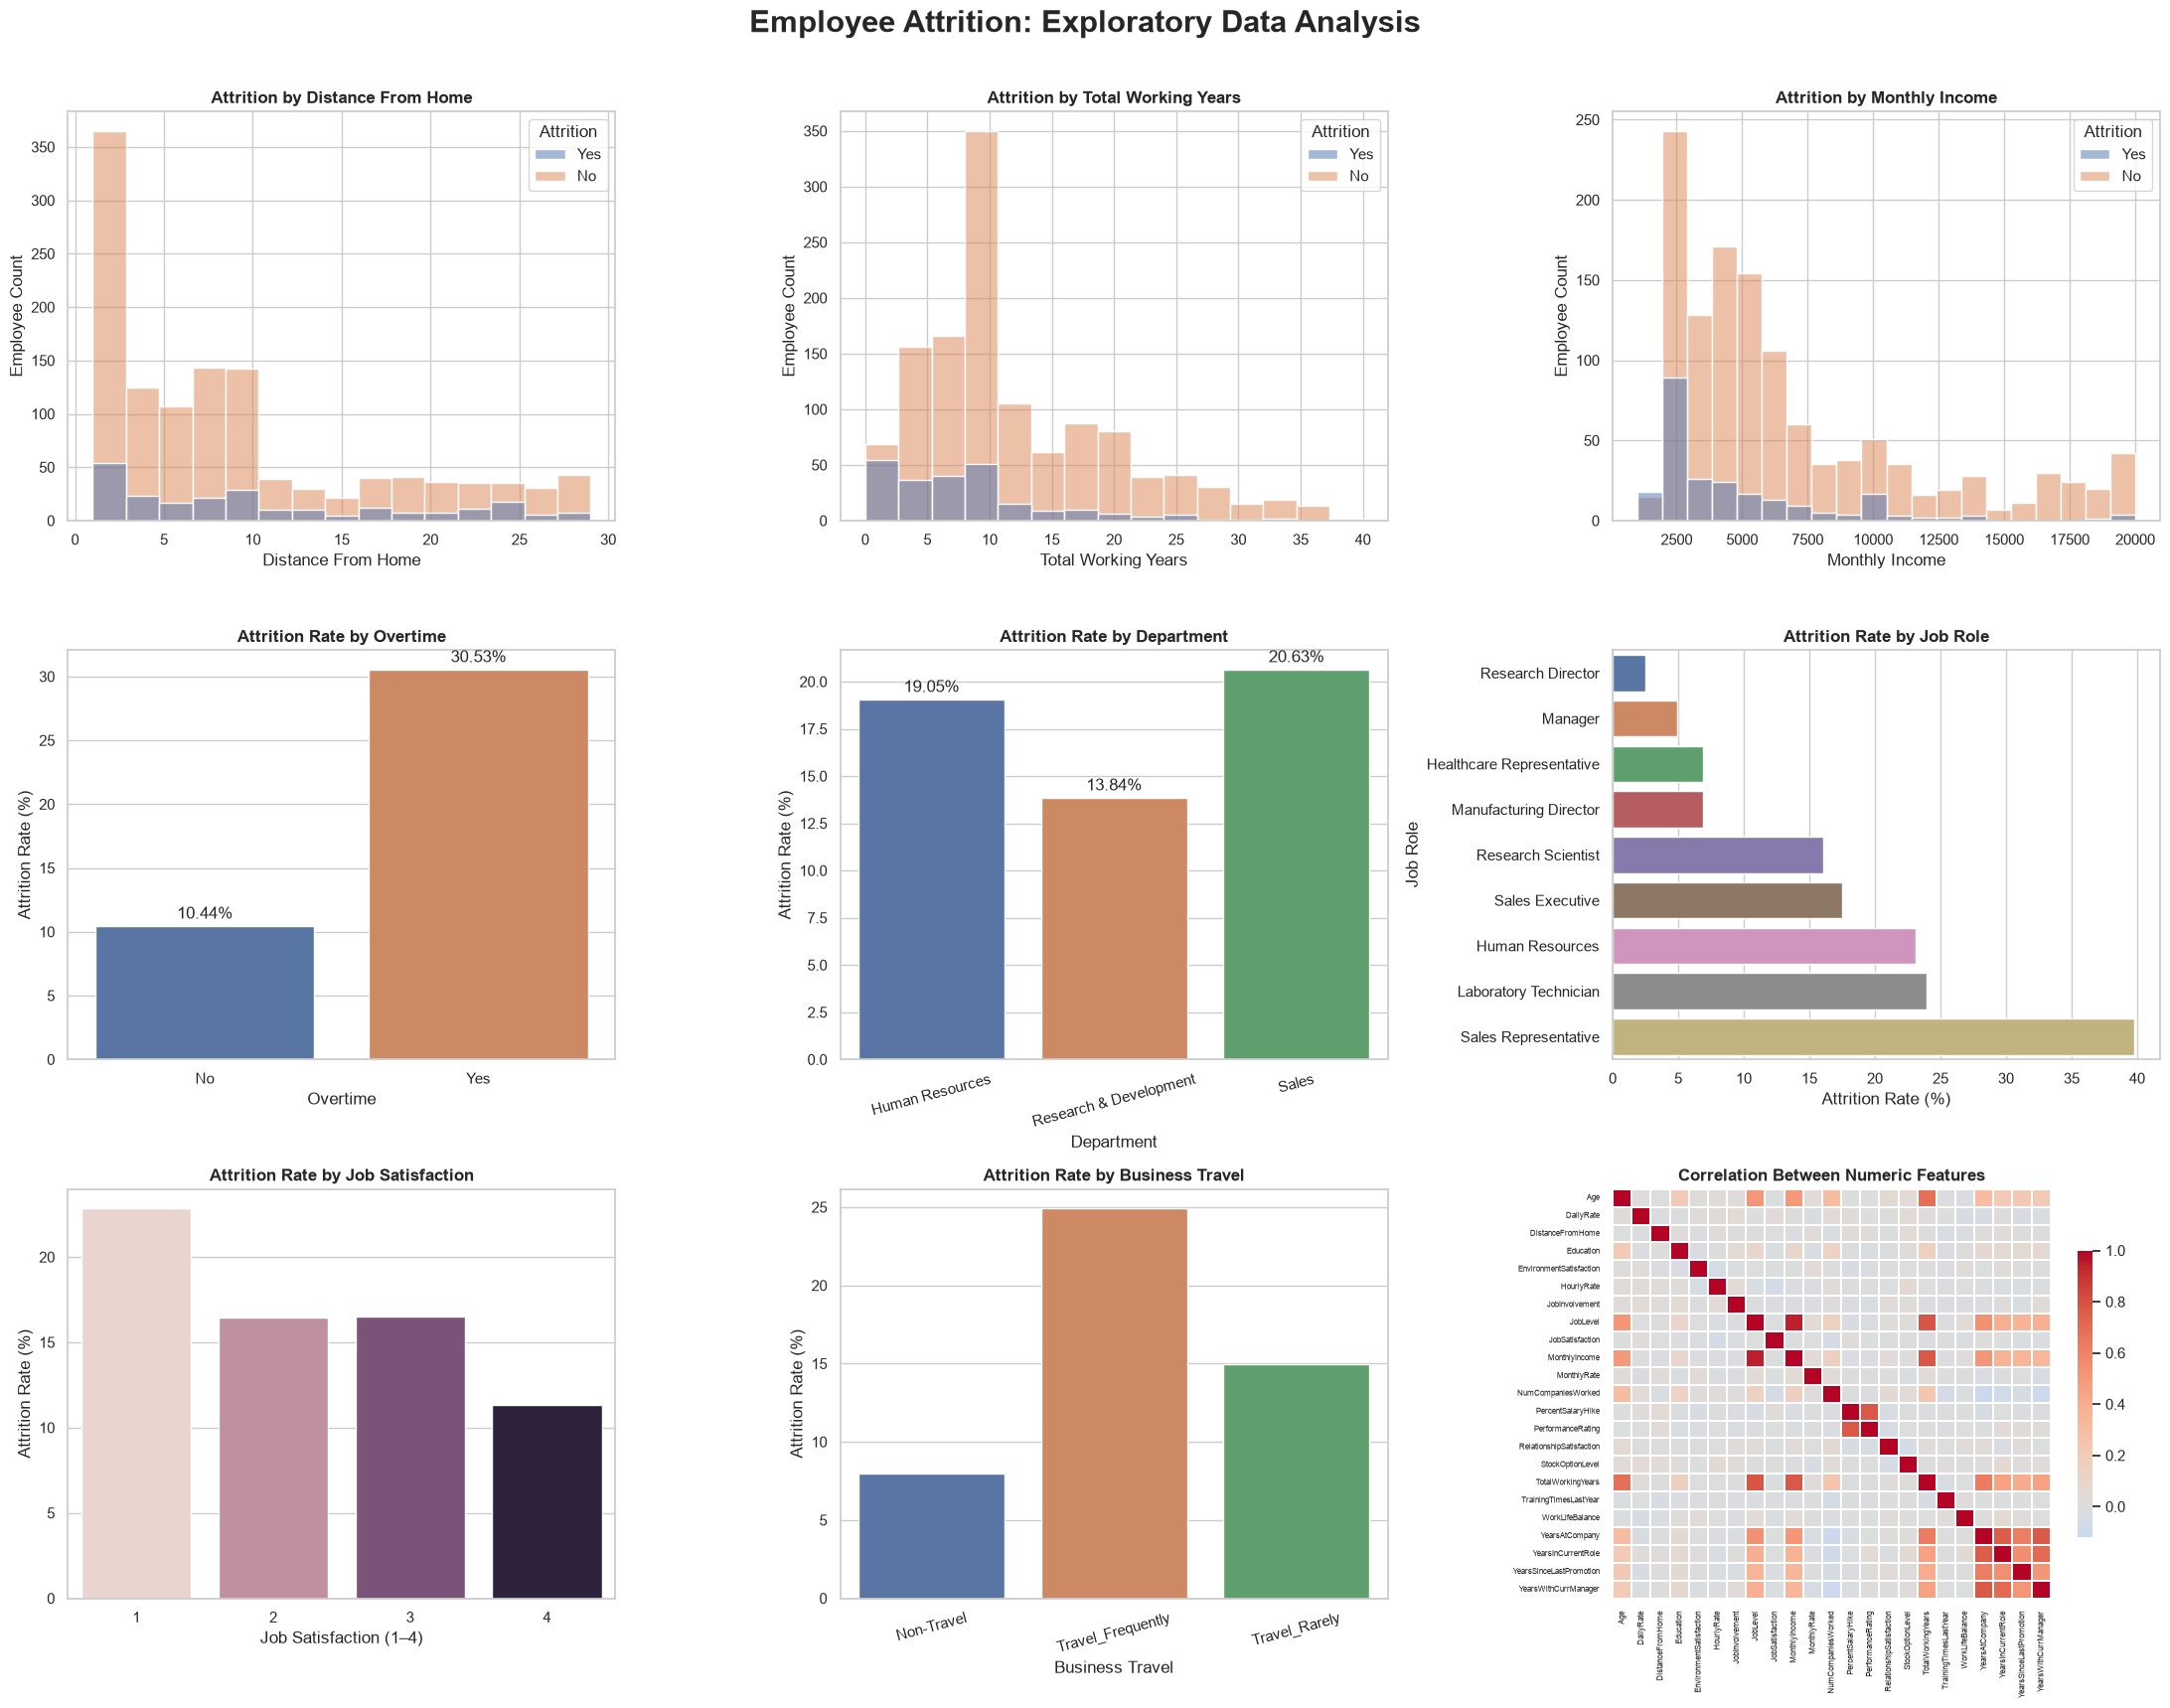

## Attrition by Overtime

OverTime,Employees,Employees Left,Attrition Rate (%)
No,"1,054",110,10.44%
Yes,416,127,30.53%


## Attrition by Department

Department,Employees,Employees Left,Attrition Rate (%)
Human Resources,63,12,19.05%
Research & Development,961,133,13.84%
Sales,446,92,20.63%


## Attrition by Job Role

...

## Attrition by Business Travel

BusinessTravel,Employees,Employees Left,Attrition Rate (%)
Non-Travel,150,12,8.00%
Travel_Frequently,277,69,24.91%
Travel_Rarely,"1,043",156,14.96%


## Key Observations


- The dataset contains **1,470 employees**.
- **237 employees** left, giving an overall attrition
  rate of **16.12%**.
- The overtime group with the highest observed attrition rate is
  **Yes**, at
  **30.53%**.
- The department with the highest observed attrition rate is
  **Sales**, at
  **20.63%**.
- The job role with the highest observed attrition rate is
  **Sales Representative**, at
  **39.76%**.
- Histograms show distributions of employee counts, not attrition rates.
- Observed relationships do not prove causation.


EDA dashboard generated successfully.


In [21]:

# ============================================================
# WORKFORCE INTELLIGENCE & EMPLOYEE ATTRITION ANALYTICS
# CONSOLIDATED EXPLORATORY DATA ANALYSIS DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# ============================================================
# 1. DASHBOARD CONFIGURATION
# ============================================================

sns.set_theme(style="whitegrid", context="notebook")

# Work on a copy to preserve the original cleaned dataset
eda_df = df_clean.copy()

# Standardize Attrition labels
eda_df["Attrition"] = (
    eda_df["Attrition"].astype(str).str.strip()
)

# Create a binary indicator for calculations
eda_df["AttritionFlag"] = (
    eda_df["Attrition"].eq("Yes").astype(int)
)

# Overall workforce metrics
total_employees = len(eda_df)
employees_left = int(eda_df["AttritionFlag"].sum())
active_employees = total_employees - employees_left

attrition_rate = (
    employees_left / total_employees * 100
    if total_employees > 0 else 0
)

display(Markdown(
    "# Workforce Intelligence | EDA Dashboard"
))

display(Markdown(
    "An exploratory overview of workforce composition, employee "
    "attrition, experience, compensation, overtime, and job satisfaction."
))

# ============================================================
# 2. KPI SUMMARY
# ============================================================

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Active Employees",
        "Employees Who Left",
        "Overall Attrition Rate"
    ],
    "Value": [
        f"{total_employees:,}",
        f"{active_employees:,}",
        f"{employees_left:,}",
        f"{attrition_rate:.2f}%"
    ]
})

display(
    kpi_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "10px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#25324A"),
                ("color", "white"),
                ("text-align", "center"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("font-size", "14px"),
                ("border-bottom", "1px solid #dddddd")
            ]
        }
    ])
)

# ============================================================
# 3. PREPARE ATTRITION SUMMARY TABLES
# ============================================================

# Overtime summary
overtime_summary = (
    eda_df.groupby("OverTime", observed=True)
    .agg(
        Employees=("EmployeeNumber", "count"),
        EmployeesLeft=("AttritionFlag", "sum"),
        AttritionRate=("AttritionFlag", "mean")
    )
    .reset_index()
)

overtime_summary["AttritionRate"] *= 100

# Department summary
department_summary = (
    eda_df.groupby("Department", observed=True)
    .agg(
        Employees=("EmployeeNumber", "count"),
        EmployeesLeft=("AttritionFlag", "sum"),
        AttritionRate=("AttritionFlag", "mean")
    )
    .reset_index()
)

department_summary["AttritionRate"] *= 100

# Job-role summary
role_summary = (
    eda_df.groupby("JobRole", observed=True)
    .agg(
        Employees=("EmployeeNumber", "count"),
        EmployeesLeft=("AttritionFlag", "sum"),
        AttritionRate=("AttritionFlag", "mean")
    )
    .reset_index()
)

role_summary["AttritionRate"] *= 100

# Job satisfaction summary
satisfaction_summary = (
    eda_df.groupby("JobSatisfaction", observed=True)
    .agg(
        Employees=("EmployeeNumber", "count"),
        EmployeesLeft=("AttritionFlag", "sum"),
        AttritionRate=("AttritionFlag", "mean")
    )
    .reset_index()
)

satisfaction_summary["AttritionRate"] *= 100

# Business travel summary
travel_summary = (
    eda_df.groupby("BusinessTravel", observed=True)
    .agg(
        Employees=("EmployeeNumber", "count"),
        EmployeesLeft=("AttritionFlag", "sum"),
        AttritionRate=("AttritionFlag", "mean")
    )
    .reset_index()
)

travel_summary["AttritionRate"] *= 100

# ============================================================
# 4. CONSOLIDATED NINE-VISUALIZATION DASHBOARD
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(22, 17))

fig.suptitle(
    "Employee Attrition: Exploratory Data Analysis",
    fontsize=22,
    fontweight="bold",
    y=1.01
)

# ------------------------------------------------------------
# CHART 1: ATTRITION BY DISTANCE FROM HOME
# ------------------------------------------------------------

sns.histplot(
    data=eda_df,
    x="DistanceFromHome",
    hue="Attrition",
    bins=15,
    multiple="layer",
    alpha=0.5,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Attrition by Distance From Home",
    fontweight="bold"
)
axes[0, 0].set_xlabel("Distance From Home")
axes[0, 0].set_ylabel("Employee Count")

# ------------------------------------------------------------
# CHART 2: ATTRITION BY TOTAL WORKING YEARS
# ------------------------------------------------------------

sns.histplot(
    data=eda_df,
    x="TotalWorkingYears",
    hue="Attrition",
    bins=15,
    multiple="layer",
    alpha=0.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Attrition by Total Working Years",
    fontweight="bold"
)
axes[0, 1].set_xlabel("Total Working Years")
axes[0, 1].set_ylabel("Employee Count")

# ------------------------------------------------------------
# CHART 3: ATTRITION BY MONTHLY INCOME
# ------------------------------------------------------------

sns.histplot(
    data=eda_df,
    x="MonthlyIncome",
    hue="Attrition",
    bins=20,
    multiple="layer",
    alpha=0.5,
    ax=axes[0, 2]
)

axes[0, 2].set_title(
    "Attrition by Monthly Income",
    fontweight="bold"
)
axes[0, 2].set_xlabel("Monthly Income")
axes[0, 2].set_ylabel("Employee Count")

# ------------------------------------------------------------
# CHART 4: ATTRITION RATE BY OVERTIME
# ------------------------------------------------------------

sns.barplot(
    data=overtime_summary,
    x="OverTime",
    y="AttritionRate",
    hue="OverTime",
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Attrition Rate by Overtime",
    fontweight="bold"
)
axes[1, 0].set_xlabel("Overtime")
axes[1, 0].set_ylabel("Attrition Rate (%)")

for container in axes[1, 0].containers:
    axes[1, 0].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

# ------------------------------------------------------------
# CHART 5: ATTRITION RATE BY DEPARTMENT
# ------------------------------------------------------------

sns.barplot(
    data=department_summary,
    x="Department",
    y="AttritionRate",
    hue="Department",
    legend=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Attrition Rate by Department",
    fontweight="bold"
)
axes[1, 1].set_xlabel("Department")
axes[1, 1].set_ylabel("Attrition Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=15)

for container in axes[1, 1].containers:
    axes[1, 1].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

# ------------------------------------------------------------
# CHART 6: ATTRITION RATE BY JOB ROLE
# ------------------------------------------------------------

role_plot = role_summary.sort_values("AttritionRate")

sns.barplot(
    data=role_plot,
    x="AttritionRate",
    y="JobRole",
    hue="JobRole",
    legend=False,
    ax=axes[1, 2]
)

axes[1, 2].set_title(
    "Attrition Rate by Job Role",
    fontweight="bold"
)
axes[1, 2].set_xlabel("Attrition Rate (%)")
axes[1, 2].set_ylabel("Job Role")

# ------------------------------------------------------------
# CHART 7: ATTRITION RATE BY JOB SATISFACTION
# ------------------------------------------------------------

sns.barplot(
    data=satisfaction_summary,
    x="JobSatisfaction",
    y="AttritionRate",
    hue="JobSatisfaction",
    legend=False,
    ax=axes[2, 0]
)

axes[2, 0].set_title(
    "Attrition Rate by Job Satisfaction",
    fontweight="bold"
)
axes[2, 0].set_xlabel("Job Satisfaction (1–4)")
axes[2, 0].set_ylabel("Attrition Rate (%)")

# ------------------------------------------------------------
# CHART 8: ATTRITION RATE BY BUSINESS TRAVEL
# ------------------------------------------------------------

sns.barplot(
    data=travel_summary,
    x="BusinessTravel",
    y="AttritionRate",
    hue="BusinessTravel",
    legend=False,
    ax=axes[2, 1]
)

axes[2, 1].set_title(
    "Attrition Rate by Business Travel",
    fontweight="bold"
)
axes[2, 1].set_xlabel("Business Travel")
axes[2, 1].set_ylabel("Attrition Rate (%)")
axes[2, 1].tick_params(axis="x", rotation=15)

# ------------------------------------------------------------
# CHART 9: CORRELATION HEATMAP
# ------------------------------------------------------------

numeric_df = eda_df.select_dtypes(include=np.number)

numeric_df = numeric_df.drop(
    columns=["EmployeeNumber", "AttritionFlag"],
    errors="ignore"
)

correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    ax=axes[2, 2],
    cbar_kws={"shrink": 0.7}
)

axes[2, 2].set_title(
    "Correlation Between Numeric Features",
    fontweight="bold"
)
axes[2, 2].tick_params(
    axis="x",
    rotation=90,
    labelsize=6
)
axes[2, 2].tick_params(
    axis="y",
    labelsize=6
)

# Final chart layout
plt.tight_layout()
plt.show()

# ============================================================
# 5. PROFESSIONAL TABLE STYLING
# ============================================================

def style_attrition_table(data, group_column):
    """Format an attrition summary table for notebook display."""

    table = data[
        [group_column, "Employees", "EmployeesLeft", "AttritionRate"]
    ].rename(columns={
        group_column: group_column.replace("_", " "),
        "Employees": "Employees",
        "EmployeesLeft": "Employees Left",
        "AttritionRate": "Attrition Rate (%)"
    })

    return (
        table.style
        .format({
            "Employees": "{:,.0f}",
            "Employees Left": "{:,.0f}",
            "Attrition Rate (%)": "{:.2f}%"
        })
        .hide(axis="index")
        .background_gradient(
            subset=["Attrition Rate (%)"],
            cmap="OrRd"
        )
        .set_properties(**{
            "text-align": "center",
            "padding": "8px"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#25324A"),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("padding", "10px")
                ]
            }
        ])
    )

# Overtime table
display(Markdown("## Attrition by Overtime"))
display(style_attrition_table(overtime_summary, "OverTime"))

# Department table
display(Markdown("## Attrition by Department"))
display(style_attrition_table(department_summary, "Department"))

# Job role table
display(Markdown("## Attrition by Job Role"))
display(style_attrition_table(role_summary, "JobRole"))

# Job satisfaction table
display(Markdown("## Attrition by Job Satisfaction"))
display(style_attrition_table(satisfaction_summary, "JobSatisfaction"))

# Business travel table
display(Markdown("## Attrition by Business Travel"))
display(style_attrition_table(travel_summary, "BusinessTravel"))

# ============================================================
# 6. KEY OBSERVATIONS
# ============================================================

highest_overtime = overtime_summary.loc[
    overtime_summary["AttritionRate"].idxmax()
]

highest_department = department_summary.loc[
    department_summary["AttritionRate"].idxmax()
]

highest_role = role_summary.loc[
    role_summary["AttritionRate"].idxmax()
]

display(Markdown("## Key Observations"))

display(Markdown(
    f"""
- The dataset contains **{total_employees:,} employees**.
- **{employees_left:,} employees** left, giving an overall attrition
  rate of **{attrition_rate:.2f}%**.
- The overtime group with the highest observed attrition rate is
  **{highest_overtime['OverTime']}**, at
  **{highest_overtime['AttritionRate']:.2f}%**.
- The department with the highest observed attrition rate is
  **{highest_department['Department']}**, at
  **{highest_department['AttritionRate']:.2f}%**.
- The job role with the highest observed attrition rate is
  **{highest_role['JobRole']}**, at
  **{highest_role['AttritionRate']:.2f}%**.
- Histograms show distributions of employee counts, not attrition rates.
- Observed relationships do not prove causation.
"""
))

print("EDA dashboard generated successfully.")


## 4. Executive Summary: Key Business Insights

### 4.1 Overall Attrition

The dataset contains 1,470 employees, of whom 237 left the organization, resulting in an overall attrition rate of 16.12%.

### 4.2 Overtime and Employee Retention

Employees working overtime have a substantially higher attrition rate than employees not working overtime. This pattern suggests that workload and work scheduling deserve further investigation.

### 4.3 Job Role Risk

Sales Representatives have the highest attrition rate among the listed job roles, followed by Laboratory Technicians and Human Resources employees. Retention strategies should consider role-specific working conditions rather than applying a uniform solution.

### 4.4 Department-Level Differences

Attrition varies across departments. Sales has a higher overall attrition rate than Research & Development, indicating that department-level workforce conditions warrant closer examination.

### 4.5 Compensation and Satisfaction

Attrition patterns differ across monthly income bands and job-satisfaction levels. These associations are useful for identifying employee groups for further investigation but do not independently establish the causes of employee departures.

### 4.6 Recommended Business Actions

- Review overtime allocation, workload and staffing levels.
- Investigate retention challenges in high-attrition job roles.
- Examine employee satisfaction and career-development opportunities.
- Monitor attrition by department, role and compensation band over time.
- Validate proposed interventions against additional workforce data before implementation.

### 4.7 Analytical Limitations

This analysis uses a historical employee dataset. Observed relationships should not be interpreted as proof of causation, and the findings may not represent current workforce conditions.